# 01 — Nettoyage et prétraitement des données

## Prédiction des émissions de CO₂ des véhicules

### Objectif

Ce notebook assure le nettoyage, la standardisation et le contrôle qualité
du jeu de données 2024 de l'European Environment Agency (EEA), avant les
étapes de Feature Engineering et de modélisation.

Les principales opérations réalisées sont :

- chargement et contrôle du jeu de données brut ;
- audit de la qualité des données ;
- suppression des variables entièrement vides ;
- normalisation et standardisation du schéma ;
- contrôle des doublons et des identifiants ;
- transformation des types de données ;
- analyse et traitement des valeurs manquantes ;
- contrôle de la variable cible `co2_wltp_g_km` ;
- analyse des variables constantes et des variables à forte cardinalité ;
- sélection et justification des variables ;
- contrôles qualité finaux ;
- export du dataset nettoyé.

### Donnée d'entrée

`data/raw/data_2024.csv`

### Données de sortie

- Mode test : `data/processed/data_2024_cleaned_test.csv`
- Mode complet : `data/processed/data_2024_cleaned.csv`

In [1]:
from pathlib import Path

# ---------------------------------------------------------------------
# Configuration des chemins du projet
# ---------------------------------------------------------------------

# Point de départ : répertoire de travail courant du notebook
PROJECT_ROOT = Path.cwd().resolve()

# Recherche de la racine du projet à partir de pyproject.toml
while not (PROJECT_ROOT / "pyproject.toml").exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError(
            "Impossible de localiser la racine du projet "
            "(pyproject.toml introuvable)."
        )

    PROJECT_ROOT = PROJECT_ROOT.parent


# ---------------------------------------------------------------------
# Chemin des données brutes
# ---------------------------------------------------------------------

RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "data_2024.csv"
)


# ---------------------------------------------------------------------
# Vérification
# ---------------------------------------------------------------------

if not RAW_DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Fichier de données brutes introuvable : {RAW_DATA_PATH}"
    )

print(f"Project root : {PROJECT_ROOT}")
print(f"Raw data     : {RAW_DATA_PATH}")
print("✅ Environnement local correctement configuré.")

Project root : /home/jmbandong/projects/ml-projects/vehicle-emissions-prediction-mlops
Raw data     : /home/jmbandong/projects/ml-projects/vehicle-emissions-prediction-mlops/data/raw/data_2024.csv
✅ Environnement local correctement configuré.


In [2]:
# ---------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt
import pandas as pd

## 1. Chargement du jeu de données

Le jeu de données brut est chargé depuis le répertoire `data/raw/`.

Deux modes d'exécution sont disponibles :

- **Mode test** : chargement d'un sous-ensemble de 100 000 observations afin
  de valider rapidement les traitements du notebook ;
- **Mode complet** : chargement de l'intégralité du dataset pour produire
  le jeu de données nettoyé de référence.

Le mode test est utilisé pendant la phase de développement et de validation
du pipeline.

In [3]:
# ---------------------------------------------------------------------
# Chargement des données
# ---------------------------------------------------------------------

TEST_MODE = True
NROWS_TEST = 100_000

if TEST_MODE:
    df = pd.read_csv(
        RAW_DATA_PATH,
        sep=",",
        nrows=NROWS_TEST,
        low_memory=False,
    )

    print(f"Mode test activé : {NROWS_TEST:,} lignes chargées.")

else:
    df = pd.read_csv(
        RAW_DATA_PATH,
        sep=",",
        low_memory=False,
    )

    print("Mode complet activé : fichier intégral chargé.")

print(f"Shape du DataFrame : {df.shape}")
print(f"Nombre de colonnes  : {df.shape[1]}")

Mode test activé : 100,000 lignes chargées.
Shape du DataFrame : (100000, 40)
Nombre de colonnes  : 40


### 1.1 Contrôle initial de la structure du dataset

Un premier contrôle permet d'identifier :

- le nombre d'observations et de variables ;
- les types de données ;
- la présence de valeurs manquantes ;
- la consommation mémoire du DataFrame.

Cette inspection fournit une première vue de la structure du jeu de données
avant les opérations de nettoyage.

In [4]:
print("Affichage INFO du DataFrame")
df.info(show_counts=True)

Affichage INFO du DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 40 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    100000 non-null  int64  
 1   Country               100000 non-null  object 
 2   VFN                   99432 non-null   object 
 3   Mp                    95401 non-null   object 
 4   Mh                    100000 non-null  object 
 5   Man                   100000 non-null  object 
 6   MMS                   0 non-null       float64
 7   Tan                   99999 non-null   object 
 8   T                     99978 non-null   object 
 9   Va                    99642 non-null   object 
 10  Ve                    99570 non-null   object 
 11  Mk                    99994 non-null   object 
 12  Cn                    99994 non-null   object 
 13  Ct                    100000 non-null  object 
 14  Cr                    100

## 2. Audit de la qualité des données

### 2.1 Analyse des valeurs manquantes

Cette étape mesure, pour chaque variable :

- le nombre de valeurs manquantes ;
- le taux de valeurs manquantes ;
- le type de données ;
- l'identification des variables entièrement vides.

Les variables contenant 100 % de valeurs manquantes ne fournissent aucune
information exploitable pour l'analyse ou la modélisation et sont exclues
du jeu de données traité.

In [5]:
# ---------------------------------------------------------------------
# Audit qualité : valeurs manquantes
# ---------------------------------------------------------------------

missingness_report = (
    pd.DataFrame(
        {
            "missing_count": df.isna().sum(),
            "missing_rate_pct": df.isna().mean().mul(100),
            "dtype": df.dtypes.astype(str),
        }
    )
    .sort_values("missing_rate_pct", ascending=False)
)

missingness_report["is_fully_empty"] = (
    missingness_report["missing_rate_pct"] == 100
)

display(missingness_report)

,missing_count,missing_rate_pct,dtype,is_fully_empty
MMS,100000,100.000,float64,True
De,100000,100.000,float64,True
Vf,100000,100.000,float64,True
Ernedc (g/km),100000,100.000,float64,True
Enedc (g/km),100000,100.000,float64,True
At2 (mm),100000,100.000,float64,True
At1 (mm),100000,100.000,float64,True
W (mm),100000,100.000,float64,True
Electric range (km),79027,79.027,float64,False
z (Wh/km),79009,79.009,float64,False


### 2.2 Suppression des variables entièrement vides

L'audit précédent a identifié les variables ne contenant aucune valeur
exploitable dans le jeu de données analysé.

Ces variables sont supprimées car elles ne contribuent ni à l'analyse,
ni aux étapes ultérieures de préparation et de modélisation.

In [6]:
# ---------------------------------------------------------------------
# Suppression des colonnes entièrement vides
# ---------------------------------------------------------------------

fully_empty_columns = df.columns[df.isna().all()].tolist()

print(
    f"Nombre de colonnes entièrement vides : "
    f"{len(fully_empty_columns)}"
)

print("Colonnes concernées :")
for column in fully_empty_columns:
    print(f"  - {column}")

df = df.drop(columns=fully_empty_columns)

print(
    f"\nShape après suppression : {df.shape}"
)

Nombre de colonnes entièrement vides : 8
Colonnes concernées :
  - MMS
  - Enedc (g/km)
  - W (mm)
  - At1 (mm)
  - At2 (mm)
  - Ernedc (g/km)
  - De
  - Vf

Shape après suppression : (100000, 32)


### 2.3 Audit des noms de colonnes

In [7]:
# ---------------------------------------------------------------------
# Audit des noms de colonnes
# ---------------------------------------------------------------------

print(f"Nombre de colonnes : {len(df.columns)}\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {repr(column)}")

Nombre de colonnes : 32

01. 'ID'
02. 'Country'
03. 'VFN'
04. 'Mp'
05. 'Mh'
06. 'Man'
07. 'Tan'
08. 'T'
09. 'Va'
10. 'Ve'
11. 'Mk'
12. 'Cn'
13. 'Ct'
14. 'Cr'
15. 'r'
16. 'm (kg)'
17. 'Mt'
18. 'Ewltp (g/km)'
19. 'Ft'
20. 'Fm'
21. 'ec (cm3)'
22. 'ep (KW)'
23. 'z (Wh/km)'
24. 'IT'
25. 'Erwltp (g/km)'
26. 'Status'
27. 'year'
28. 'Date of registration'
29. 'Fuel consumption '
30. 'ech'
31. 'RLFI'
32. 'Electric range (km)'


### 2.4 Normalisation technique des noms de colonnes

In [8]:
# ---------------------------------------------------------------------
# Normalisation des noms de colonnes
# ---------------------------------------------------------------------

original_columns = df.columns.tolist()

df.columns = df.columns.str.strip()

renamed_by_strip = {
    before: after
    for before, after in zip(original_columns, df.columns)
    if before != after
}

if renamed_by_strip:
    print("Colonnes normalisées :")
    for before, after in renamed_by_strip.items():
        print(f"  {before!r} -> {after!r}")
else:
    print("Aucun espace parasite détecté dans les noms de colonnes.")

print(f"\nNombre de colonnes : {df.shape[1]}")

Colonnes normalisées :
  'Fuel consumption ' -> 'Fuel consumption'

Nombre de colonnes : 32


## 3. Standardisation du schéma de données

### 3.1 Renommage métier des variables

Les noms de colonnes fournis par la source EEA utilisent des abréviations
réglementaires ou techniques parfois peu explicites.

Cette étape applique un schéma de nommage homogène afin de :

- améliorer la lisibilité du jeu de données ;
- utiliser la convention `snake_case` ;
- faciliter la réutilisation dans les pipelines Python et MLOps ;
- disposer d'un vocabulaire métier cohérent pour l'analyse et la modélisation.

In [9]:
# ---------------------------------------------------------------------
# Standardisation métier des noms de variables
# ---------------------------------------------------------------------

COLUMN_MAPPING = {
    "ID": "vehicle_record_id",
    "Country": "country",
    "VFN": "vehicle_family_id",
    "Mp": "manufacturer_pool",
    "Mh": "manufacturer_name_eu",
    "Man": "manufacturer_name_oem",
    "Tan": "type_approval_number",
    "T": "vehicle_type",
    "Va": "vehicle_variant",
    "Ve": "vehicle_version",
    "Mk": "manufacturer_make",
    "Cn": "commercial_name",
    "Ct": "vehicle_category_type",
    "Cr": "vehicle_category",
    "r": "new_registrations",
    "m (kg)": "mass_running_order_kg",
    "Mt": "wltp_test_mass_kg",
    "Ewltp (g/km)": "co2_wltp_g_km",
    "Ft": "fuel_type",
    "Fm": "fuel_mode",
    "ec (cm3)": "engine_capacity_cm3",
    "ep (KW)": "engine_power_kw",
    "z (Wh/km)": "electric_energy_consumption_wh_km",
    "IT": "innovative_technology",
    "Erwltp (g/km)": "co2_reduction_wltp_g_km",
    "Status": "status",
    "year": "registration_year",
    "Date of registration": "registration_date",
    "Fuel consumption": "fuel_consumption",
    "ech": "emission_standard",
    "RLFI": "rlfi",
    "Electric range (km)": "electric_range_km",
}

df = df.rename(columns=COLUMN_MAPPING)

### 3.2 Validation du schéma après renommage

In [10]:
# ---------------------------------------------------------------------
# Validation du schéma après renommage
# ---------------------------------------------------------------------

print(f"Nombre de colonnes : {df.shape[1]}\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

Nombre de colonnes : 32

01. vehicle_record_id
02. country
03. vehicle_family_id
04. manufacturer_pool
05. manufacturer_name_eu
06. manufacturer_name_oem
07. type_approval_number
08. vehicle_type
09. vehicle_variant
10. vehicle_version
11. manufacturer_make
12. commercial_name
13. vehicle_category_type
14. vehicle_category
15. new_registrations
16. mass_running_order_kg
17. wltp_test_mass_kg
18. co2_wltp_g_km
19. fuel_type
20. fuel_mode
21. engine_capacity_cm3
22. engine_power_kw
23. electric_energy_consumption_wh_km
24. innovative_technology
25. co2_reduction_wltp_g_km
26. status
27. registration_year
28. registration_date
29. fuel_consumption
30. emission_standard
31. rlfi
32. electric_range_km


## 4. Contrôles d'intégrité des données

### 4.1 Détection des doublons

Cette étape vérifie la présence d'enregistrements strictement identiques
dans le jeu de données.

La détection des doublons permet de limiter :

- la surreprésentation artificielle de certains véhicules ;
- les biais statistiques ;
- les fuites d'information lors de l'entraînement ;
- les incohérences dans les traitements ultérieurs.

In [11]:
# ---------------------------------------------------------------------
# Détection des doublons
# ---------------------------------------------------------------------

duplicate_count = df.duplicated().sum()
duplicate_rate = duplicate_count / len(df) * 100

print(f"Nombre de lignes      : {len(df):,}")
print(f"Nombre de doublons    : {duplicate_count:,}")
print(f"Taux de doublons      : {duplicate_rate:.4f}%")

Nombre de lignes      : 100,000
Nombre de doublons    : 0
Taux de doublons      : 0.0000%


### 4.2 Contrôle de l'identifiant technique

La variable `vehicle_record_id` constitue un identifiant technique de l'enregistrement.

À ce stade du pipeline, elle est conservée afin de permettre :

- le contrôle de l'unicité des enregistrements ;
- la traçabilité des données ;
- le diagnostic d'éventuelles anomalies ;
- le rapprochement avec les données sources.

Cet identifiant n'a cependant pas vocation à constituer une variable explicative
du modèle de Machine Learning. Il sera explicitement exclu des features lors
de la préparation des données de modélisation.

In [12]:
# ---------------------------------------------------------------------
# Contrôle de l'identifiant technique
# ---------------------------------------------------------------------

ID_COLUMN = "vehicle_record_id"

total_rows = len(df)
missing_ids = df[ID_COLUMN].isna().sum()
unique_ids = df[ID_COLUMN].nunique(dropna=True)
duplicated_ids = df[ID_COLUMN].duplicated().sum()

print(f"Nombre d'enregistrements : {total_rows:,}")
print(f"Identifiants manquants   : {missing_ids:,}")
print(f"Identifiants uniques     : {unique_ids:,}")
print(f"Identifiants dupliqués   : {duplicated_ids:,}")

if missing_ids == 0 and duplicated_ids == 0:
    print("\n✅ L'identifiant technique est complet et unique.")
else:
    print("\n⚠️ Anomalies détectées sur l'identifiant technique.")

Nombre d'enregistrements : 100,000
Identifiants manquants   : 0
Identifiants uniques     : 100,000
Identifiants dupliqués   : 0

✅ L'identifiant technique est complet et unique.


## 5. Contrôle et transformation des types de données

Cette étape vérifie la cohérence des types de données après les premières
opérations de nettoyage.

Une attention particulière est portée aux variables temporelles
`registration_year` et `registration_date` afin de garantir des types
cohérents et exploitables dans les étapes ultérieures d'analyse,
de feature engineering et de modélisation.

Les transformations réalisées dans cette section concernent uniquement
la cohérence des types et des représentations. Les décisions relatives
aux variables constantes sont centralisées dans la section 6.

### 5.1 Contrôle de `registration_year`

La variable `registration_year` est contrôlée afin d'évaluer sa variabilité
dans le jeu de données analysé.

Une variable ne présentant qu'une seule modalité est considérée comme
constante et n'apporte pas de pouvoir discriminant pour la modélisation.

À cette étape, aucune suppression n'est réalisée. La gestion des variables
constantes est centralisée dans la section 6 afin d'appliquer une stratégie
homogène à l'ensemble des variables concernées.

In [13]:
# ---------------------------------------------------------------------
# Contrôle de la variable registration_year
# ---------------------------------------------------------------------

YEAR_COLUMN = "registration_year"

if YEAR_COLUMN not in df.columns:
    raise KeyError(
        f"La colonne '{YEAR_COLUMN}' est absente du DataFrame."
    )

year_unique_values = df[YEAR_COLUMN].nunique(dropna=False)
year_is_constant = year_unique_values == 1

print(
    f"Nombre de modalités de '{YEAR_COLUMN}' : "
    f"{year_unique_values}"
)

if year_is_constant:
    print(
        f"ℹ️ Colonne '{YEAR_COLUMN}' détectée comme constante. "
        "Son traitement sera réalisé dans la section 6."
    )
else:
    print(
        f"✅ Colonne '{YEAR_COLUMN}' non constante : "
        "plusieurs modalités détectées."
    )

Nombre de modalités de 'registration_year' : 1
ℹ️ Colonne 'registration_year' détectée comme constante. Son traitement sera réalisé dans la section 6.


### 5.2 Conversion de `registration_date` en type datetime

La variable `registration_date` est convertie vers le type temporel
`datetime64[ns]` afin de garantir sa cohérence et de permettre son exploitation
dans les analyses temporelles ultérieures.

Les valeurs qui ne peuvent pas être interprétées comme des dates valides sont
converties en valeurs manquantes (`NaT`) afin de pouvoir être identifiées et
contrôlées explicitement.

In [14]:
# ---------------------------------------------------------------------
# Conversion de la date d'immatriculation
# ---------------------------------------------------------------------

DATE_COLUMN = "registration_date"

df[DATE_COLUMN] = pd.to_datetime(
    df[DATE_COLUMN],
    errors="coerce",
)

invalid_dates = df[DATE_COLUMN].isna().sum()

print(f"Type de la colonne : {df[DATE_COLUMN].dtype}")
print(f"Dates invalides     : {invalid_dates:,}")

Type de la colonne : datetime64[ns]
Dates invalides     : 0


### 5.3 Audit des types de données après transformations

Après les opérations de contrôle et de conversion précédentes, un audit des
types de données est réalisé afin de vérifier la cohérence du DataFrame avant
les étapes suivantes de nettoyage métier et de feature engineering.

Cet audit permet notamment de contrôler :

- le type de chaque variable ;
- le nombre de valeurs manquantes ;
- le taux de valeurs manquantes ;
- le nombre de valeurs distinctes.

In [15]:
# ---------------------------------------------------------------------
# Audit synthétique des types de données
# ---------------------------------------------------------------------

dtype_report = (
    df.dtypes
    .astype(str)
    .rename("dtype")
    .to_frame()
)

dtype_report["missing_count"] = df.isna().sum()
dtype_report["missing_rate_pct"] = (
    df.isna().mean().mul(100).round(2)
)
dtype_report["unique_values"] = df.nunique(dropna=True)

display(dtype_report)

,dtype,missing_count,missing_rate_pct,unique_values
vehicle_record_id,int64,0,0.00,100000
country,object,0,0.00,3
vehicle_family_id,object,568,0.57,2988
manufacturer_pool,object,4599,4.60,11
manufacturer_name_eu,object,0,0.00,86
manufacturer_name_oem,object,0,0.00,84
type_approval_number,object,1,0.00,1679
vehicle_type,object,22,0.02,547
vehicle_variant,object,358,0.36,2261
vehicle_version,object,430,0.43,7080


## 6. Analyse des variables constantes

Les variables constantes ne présentent aucune variabilité dans le jeu de
données analysé et n'apportent donc aucun pouvoir discriminant direct à un
modèle prédictif.

Cette section vise à identifier ces variables et à déterminer leur traitement
en fonction du mode d'exécution du notebook.

### 6.1 Détection des variables constantes

Une variable est considérée comme constante lorsqu'elle ne possède qu'une
seule valeur distincte sur l'ensemble des observations analysées.

En mode test, cette détection est réalisée sur un échantillon du dataset et
doit donc être considérée comme provisoire. Le caractère constant d'une
variable devra être confirmé lors de l'exécution sur le dataset complet.

In [16]:
constant_columns = [
    column
    for column in df.columns
    if df[column].nunique(dropna=False) <= 1
]

print(f"Nombre de variables constantes : {len(constant_columns)}")

if constant_columns:
    print("\nVariables constantes détectées :")

    for column in constant_columns:
        unique_values = df[column].drop_duplicates().tolist()
        print(f"  - {column}: {unique_values}")
else:
    print("Aucune variable constante détectée.")

Nombre de variables constantes : 4

Variables constantes détectées :
  - vehicle_category: ['M1']
  - new_registrations: [1]
  - status: ['P']
  - registration_year: [2024]


### 6.2 Stratégie de traitement des variables constantes

Les variables constantes ne présentent aucune variance et n'apportent donc
aucun pouvoir discriminant pour la modélisation.

En mode test, les variables constantes sont uniquement identifiées et
enregistrées comme candidates à la suppression.

En mode complet, leur caractère constant est vérifié sur l'ensemble du jeu
de données avant leur suppression définitive.

Cette approche évite de supprimer une variable qui serait constante sur
l'échantillon de développement mais variable sur le jeu de données complet.

In [17]:
# ---------------------------------------------------------------------
# Traitement contrôlé des variables constantes
# ---------------------------------------------------------------------

if TEST_MODE:
    constant_columns_to_drop = constant_columns.copy()

    print("Mode test activé.")
    print(
        "Les variables suivantes sont candidates à la suppression, "
        "mais sont conservées pour l'instant :"
    )

    for column in constant_columns_to_drop:
        print(f"  - {column}")

else:
    df = df.drop(columns=constant_columns)

    print(
        f"{len(constant_columns)} variable(s) constante(s) "
        "supprimée(s) du jeu de données complet :"
    )

    for column in constant_columns:
        print(f"  - {column}")

Mode test activé.
Les variables suivantes sont candidates à la suppression, mais sont conservées pour l'instant :
  - vehicle_category
  - new_registrations
  - status
  - registration_year


## 7. Contrôle qualité des variables catégorielles

### 7.1 Inventaire et cardinalité des variables catégorielles

Cette étape établit un profil des variables catégorielles avant leur nettoyage
et leur éventuel encodage.

Pour chaque variable catégorielle, l'analyse porte sur :

- le nombre de modalités distinctes ;
- le nombre de valeurs manquantes ;
- le taux de valeurs manquantes ;
- le niveau de cardinalité.

Cette analyse permet notamment de distinguer les variables à faible cardinalité,
adaptées à une inspection détaillée, des variables à forte cardinalité qui
nécessitent une stratégie de traitement spécifique.

In [18]:
# ---------------------------------------------------------------------
# Inventaire des variables catégorielles
# ---------------------------------------------------------------------

categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

categorical_summary = pd.DataFrame(
    {
        "column": categorical_columns,
        "unique_values": [
            df[column].nunique(dropna=True)
            for column in categorical_columns
        ],
        "missing_count": [
            df[column].isna().sum()
            for column in categorical_columns
        ],
        "missing_rate_pct": [
            round(df[column].isna().mean() * 100, 2)
            for column in categorical_columns
        ],
    }
).sort_values(
    by="unique_values",
    ascending=True,
).reset_index(drop=True)

display(categorical_summary)

,column,unique_values,missing_count,missing_rate_pct
0,vehicle_category,1,0,0.00
1,status,1,0,0.00
2,vehicle_category_type,2,0,0.00
3,country,3,0,0.00
4,fuel_mode,6,0,0.00
5,fuel_type,9,0,0.00
6,manufacturer_pool,11,4599,4.60
7,emission_standard,32,12,0.01
8,innovative_technology,72,43887,43.89
9,manufacturer_name_oem,84,0,0.00


### 7.2 Classification des variables selon leur cardinalité

Les variables catégorielles sont regroupées selon leur nombre de modalités
distinctes afin d'adapter les stratégies d'analyse et de transformation.

La classification retenue pour l'audit est la suivante :

- **faible cardinalité** : jusqu'à 20 modalités ;
- **cardinalité intermédiaire** : de 21 à 100 modalités ;
- **forte cardinalité** : plus de 100 modalités.

Ces seuils constituent des règles d'analyse et non des critères automatiques
d'encodage. Le choix final dépendra également de la signification métier de
chaque variable et de son utilisation dans le modèle.

In [19]:
# ---------------------------------------------------------------------
# Classification des variables catégorielles par cardinalité
# ---------------------------------------------------------------------

def classify_cardinality(n_unique):
    if n_unique <= 20:
        return "low"
    elif n_unique <= 100:
        return "medium"
    return "high"


categorical_summary["cardinality_level"] = (
    categorical_summary["unique_values"]
    .apply(classify_cardinality)
)

display(categorical_summary)

,column,unique_values,missing_count,missing_rate_pct,cardinality_level
0,vehicle_category,1,0,0.00,low
1,status,1,0,0.00,low
2,vehicle_category_type,2,0,0.00,low
3,country,3,0,0.00,low
4,fuel_mode,6,0,0.00,low
5,fuel_type,9,0,0.00,low
6,manufacturer_pool,11,4599,4.60,low
7,emission_standard,32,12,0.01,medium
8,innovative_technology,72,43887,43.89,medium
9,manufacturer_name_oem,84,0,0.00,medium


### 7.3 Audit détaillé des variables à faible cardinalité

Les variables à faible cardinalité font l'objet d'une inspection détaillée
de leurs modalités et de leurs fréquences.

Cette analyse vise à identifier :

- les modalités dominantes ou très rares ;
- les éventuelles incohérences de casse ou d'écriture ;
- les espaces parasites ;
- les valeurs manquantes ;
- les catégories susceptibles d'être regroupées ;
- les variables constantes déjà identifiées.

Aucune transformation n'est appliquée à cette étape : il s'agit d'un audit
préalable aux décisions de nettoyage et d'encodage.

In [20]:
# ---------------------------------------------------------------------
# Audit détaillé des variables catégorielles à faible cardinalité
# ---------------------------------------------------------------------

low_cardinality_columns = categorical_summary.loc[
    categorical_summary["cardinality_level"] == "low",
    "column",
].tolist()

print(
    f"Nombre de variables catégorielles à faible cardinalité : "
    f"{len(low_cardinality_columns)}"
)

for column in low_cardinality_columns:
    print("\n" + "=" * 70)
    print(f"Variable : {column}")
    print("=" * 70)

    counts = df[column].value_counts(
        dropna=False
    )

    percentages = df[column].value_counts(
        dropna=False,
        normalize=True
    ).mul(100)

    category_report = pd.DataFrame(
        {
            "count": counts,
            "percentage": percentages.round(2),
        }
    )

    display(category_report)

Nombre de variables catégorielles à faible cardinalité : 7

Variable : vehicle_category


,count,percentage
vehicle_category,,
M1,100000,100.0



Variable : status


,count,percentage
status,,
P,100000,100.0



Variable : vehicle_category_type


...

,count,percentage
fuel_mode,,
M,47215,47.22
H,30049,30.05
E,14152,14.15
P,7023,7.02
B,1534,1.53
F,27,0.03



Variable : fuel_type


,count,percentage
fuel_type,,
petrol,60150,60.15
diesel,16595,16.60
electric,14152,14.15
petrol/electric,6544,6.54
lpg,1534,1.53
e85,522,0.52
diesel/electric,479,0.48
hydrogen,14,0.01
ng,10,0.01



Variable : manufacturer_pool


,count,percentage
manufacturer_pool,,
VOLKSWAGEN,30685,30.68
STELLANTIS,17157,17.16
RENAULT-NISSAN-MITSUBISHI,14864,14.86
BMW,7434,7.43
SUBARU-MAZDA-TOYOTA,6622,6.62
MERCEDES-BENZ AG,6535,6.54
NaN,4599,4.60
HYUNDAI MOTOR EUROPE,3461,3.46
VOLVO CARS POLESTAR SUZUKI,2903,2.90


### 7.4 Normalisation des modalités catégorielles

Les variables catégorielles peuvent présenter des différences de représentation
qui créent artificiellement plusieurs modalités pour une même information métier.

La normalisation est réalisée selon deux niveaux complémentaires :

#### 1. Normalisation technique générale

Une normalisation minimale et non destructive est appliquée à l'ensemble des
variables catégorielles :

- suppression des espaces parasites en début et fin de chaîne ;
- conservation des valeurs manquantes ;
- conservation de la casse lorsque celle-ci n'a pas été identifiée comme une
  source d'incohérence métier.

Cette étape évite d'appliquer une transformation globale susceptible de modifier
la sémantique de certaines variables catégorielles.

#### 2. Normalisation métier spécifique

Des règles supplémentaires sont appliquées uniquement aux variables pour
lesquelles elles sont sémantiquement justifiées.

Pour les codes réglementaires ou techniques suivants, la casse ne porte pas
d'information métier :

- `vehicle_category_type` ;
- `fuel_mode`.

Leurs modalités sont donc normalisées en majuscules afin d'éviter la création
de catégories artificiellement distinctes.

Exemples :

- `m1` → `M1`
- `n1` → `N1`
- `m1g` → `M1G`
- `b` → `B`
- `h` → `H`

La variable `manufacturer_make` n'est volontairement pas normalisée par cette
règle générique. Elle présente des problématiques spécifiques de qualité des
données (variantes typographiques, redondances, valeurs anormales, etc.) et fait
l'objet d'un traitement métier dédié.

In [21]:
# ---------------------------------------------------------------------
# Normalisation des modalités catégorielles
# ---------------------------------------------------------------------

CATEGORICAL_CODE_NORMALIZATION = {
    "vehicle_category_type": "upper",
    "fuel_mode": "upper",
}


def normalize_text_values(
    series: pd.Series,
) -> pd.Series:
    """
    Applique la normalisation technique générale
    d'une variable catégorielle.

    Les valeurs manquantes sont conservées.
    """

    result = series.copy()

    mask = result.notna()

    result.loc[mask] = (
        result.loc[mask]
        .astype(str)
        .str.strip()
    )

    return result


def normalize_categorical_values(
    df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Normalise les variables catégorielles selon deux niveaux :

    1. nettoyage technique général ;
    2. règles métier spécifiques aux codes catégoriels.
    """

    df = df.copy()

    categorical_columns = df.select_dtypes(
        include=[
            "object",
            "string",
            "category",
        ]
    ).columns

    # -----------------------------------------------------------------
    # 1. Normalisation technique générale
    # -----------------------------------------------------------------

    for column in categorical_columns:

        df[column] = normalize_text_values(
            df[column]
        )

    # -----------------------------------------------------------------
    # 2. Normalisation métier spécifique
    # -----------------------------------------------------------------

    for column, normalization in (
        CATEGORICAL_CODE_NORMALIZATION.items()
    ):

        if column not in df.columns:
            continue

        mask = df[column].notna()

        if normalization == "upper":

            df.loc[mask, column] = (
                df.loc[mask, column]
                .astype(str)
                .str.upper()
            )

    return df


df = normalize_categorical_values(df)

print(
    "✅ Normalisation des modalités catégorielles appliquée."
)

✅ Normalisation des modalités catégorielles appliquée.


### 7.5 Normalisation dédiée de `manufacturer_make`

La variable `manufacturer_make`, issue de la colonne source `Mk`, représente la
marque du véhicule.

Contrairement aux codes catégoriels normalisés précédemment, cette variable
nécessite un traitement dédié afin d'obtenir des modalités cohérentes avant
leur utilisation dans les étapes de Feature Engineering et de Machine Learning.

La normalisation appliquée vise à :

- supprimer les espaces parasites ;
- harmoniser les différences de casse ;
- réduire les variations typographiques liées aux espaces, tirets,
  ponctuations ou séparateurs ;
- regrouper les variantes typographiques correspondant à une même marque ;
- identifier les valeurs qui ne correspondent pas à une marque textuelle
  exploitable ;
- utiliser, lorsque cela est nécessaire et suffisamment fiable, les variables
  `manufacturer_name_eu` et `manufacturer_name_oem` comme informations
  complémentaires pour déterminer une marque cohérente.

La stratégie de traitement reste conservative :

1. une clé de comparaison normalisée est construite pour identifier les
   variantes typographiques d'une même marque ;
2. pour chaque groupe de variantes équivalentes, la modalité observée la plus
   fréquemment est retenue comme valeur canonique ;
3. les valeurs non textuelles ou non directement exploitables sont rapprochées
   des informations constructeur disponibles dans
   `manufacturer_name_eu` et `manufacturer_name_oem` ;
4. une résolution automatique n'est appliquée que lorsque la correspondance
   avec une marque est suffisamment dominante ;
5. les cas ne pouvant pas être résolus de manière fiable sont conservés comme
   valeurs manquantes afin d'éviter toute attribution arbitraire.

Cette étape permet d'obtenir une variable `manufacturer_make` plus homogène,
tout en préservant la signification métier des marques et en limitant les
regroupements aux correspondances suffisamment fiables.

In [22]:
# ---------------------------------------------------------------------
# 7.5 Normalisation dédiée de manufacturer_make
# ---------------------------------------------------------------------

MANUFACTURER_RESOLUTION_MIN_SHARE = 0.95


def build_manufacturer_comparison_key(
    series: pd.Series,
) -> pd.Series:
    """
    Construit une clé technique de comparaison permettant
    d'identifier les variantes typographiques d'une même marque.

    Exemples :
    - 'MERCEDES-BENZ'   -> 'MERCEDES BENZ'
    - 'Mercedes Benz'   -> 'MERCEDES BENZ'
    - 'MERCEDES - BENZ' -> 'MERCEDES BENZ'
    """

    result = (
        series
        .astype("string")
        .str.strip()
        .str.upper()
    )

    # Uniformisation des séparateurs courants
    result = result.str.replace(
        r"[.\-_/]+",
        " ",
        regex=True,
    )

    # Réduction des espaces multiples
    result = result.str.replace(
        r"\s+",
        " ",
        regex=True,
    )

    return result.str.strip()


def normalize_manufacturer_make(
    df: pd.DataFrame,
    min_resolution_share: float = (
        MANUFACTURER_RESOLUTION_MIN_SHARE
    ),
) -> tuple[pd.DataFrame, dict]:
    """
    Normalise manufacturer_make selon une stratégie conservative.

    Étapes :
    1. normalisation typographique des valeurs textuelles ;
    2. regroupement des variantes équivalentes ;
    3. sélection d'une valeur canonique ;
    4. résolution des valeurs non textuelles à partir de
       manufacturer_name_eu / manufacturer_name_oem ;
    5. conservation en valeur manquante des cas ambigus.
    """

    required_columns = {
        "manufacturer_make",
        "manufacturer_name_eu",
        "manufacturer_name_oem",
    }

    missing_columns = sorted(
        required_columns - set(df.columns)
    )

    if missing_columns:
        raise ValueError(
            "Colonnes indispensables absentes pour la "
            "normalisation de manufacturer_make : "
            + ", ".join(missing_columns)
        )

    if not 0 < min_resolution_share <= 1:
        raise ValueError(
            "min_resolution_share doit être compris "
            "dans l'intervalle ]0, 1]."
        )

    df = df.copy()

    manufacturer = (
        df["manufacturer_make"]
        .astype("string")
        .str.strip()
    )

    numeric_mask = manufacturer.str.fullmatch(
        r"\d+",
        na=False,
    )

    textual_mask = (
        manufacturer.notna()
        & ~numeric_mask
    )

    numeric_before = int(
        numeric_mask.sum()
    )


    # =================================================================
    # 1. Normalisation typographique des valeurs textuelles
    # =================================================================

    comparison_key = (
        build_manufacturer_comparison_key(
            manufacturer
        )
    )

    textual_reference = pd.DataFrame(
        {
            "manufacturer_make":
                manufacturer[textual_mask],

            "comparison_key":
                comparison_key[textual_mask],
        }
    )

    variant_counts = (
        textual_reference
        .value_counts(
            [
                "comparison_key",
                "manufacturer_make",
            ]
        )
        .rename("observations")
        .reset_index()
    )

    canonical_variants = (
        variant_counts
        .sort_values(
            by=[
                "comparison_key",
                "observations",
                "manufacturer_make",
            ],
            ascending=[
                True,
                False,
                True,
            ],
        )
        .drop_duplicates(
            subset="comparison_key",
            keep="first",
        )
        .set_index(
            "comparison_key"
        )[
            "manufacturer_make"
        ]
    )

    df.loc[
        textual_mask,
        "manufacturer_make",
    ] = (
        comparison_key[textual_mask]
        .map(
            canonical_variants
        )
        .astype("string")
    )


    # =================================================================
    # 2. Référentiel fiable :
    #    (manufacturer_name_eu, manufacturer_name_oem)
    #    -> manufacturer_make
    # =================================================================

    textual_rows = df.loc[
        textual_mask,
        [
            "manufacturer_make",
            "manufacturer_name_eu",
            "manufacturer_name_oem",
        ],
    ].copy()

    for column in [
        "manufacturer_name_eu",
        "manufacturer_name_oem",
    ]:

        textual_rows[column] = (
            textual_rows[column]
            .astype("string")
            .str.strip()
            .str.upper()
        )

    valid_reference_mask = (
        textual_rows[
            "manufacturer_name_eu"
        ].notna()
        & textual_rows[
            "manufacturer_name_oem"
        ].notna()
    )

    reference_counts = (
        textual_rows.loc[
            valid_reference_mask
        ]
        .value_counts(
            [
                "manufacturer_name_eu",
                "manufacturer_name_oem",
                "manufacturer_make",
            ]
        )
        .rename("observations")
        .reset_index()
    )

    pair_totals = (
        reference_counts
        .groupby(
            [
                "manufacturer_name_eu",
                "manufacturer_name_oem",
            ],
            as_index=False,
        )[
            "observations"
        ]
        .sum()
        .rename(
            columns={
                "observations":
                    "pair_observations"
            }
        )
    )

    reference_counts = (
        reference_counts
        .merge(
            pair_totals,
            on=[
                "manufacturer_name_eu",
                "manufacturer_name_oem",
            ],
            how="left",
        )
    )

    reference_counts[
        "share"
    ] = (
        reference_counts[
            "observations"
        ]
        / reference_counts[
            "pair_observations"
        ]
    )

    dominant_reference = (
        reference_counts
        .sort_values(
            by=[
                "manufacturer_name_eu",
                "manufacturer_name_oem",
                "observations",
            ],
            ascending=[
                True,
                True,
                False,
            ],
        )
        .drop_duplicates(
            subset=[
                "manufacturer_name_eu",
                "manufacturer_name_oem",
            ],
            keep="first",
        )
    )

    reliable_reference = (
        dominant_reference[
            dominant_reference[
                "share"
            ]
            >= min_resolution_share
        ]
        .copy()
    )

    resolution_map = {
        (
            row[
                "manufacturer_name_eu"
            ],
            row[
                "manufacturer_name_oem"
            ],
        ):
            row[
                "manufacturer_make"
            ]

        for _, row
        in reliable_reference.iterrows()
    }


    # =================================================================
    # 3. Résolution des valeurs manufacturer_make numériques
    # =================================================================

    numeric_rows = df.loc[
        numeric_mask,
        [
            "manufacturer_name_eu",
            "manufacturer_name_oem",
        ],
    ].copy()

    for column in [
        "manufacturer_name_eu",
        "manufacturer_name_oem",
    ]:

        numeric_rows[column] = (
            numeric_rows[column]
            .astype("string")
            .str.strip()
            .str.upper()
        )

    resolved_values = pd.Series(
        pd.NA,
        index=numeric_rows.index,
        dtype="string",
    )

    for index, row in numeric_rows.iterrows():

        manufacturer_pair = (
            row[
                "manufacturer_name_eu"
            ],
            row[
                "manufacturer_name_oem"
            ],
        )

        resolved_values.loc[
            index
        ] = resolution_map.get(
            manufacturer_pair,
            pd.NA,
        )

    resolved_mask = (
        resolved_values.notna()
    )

    df.loc[
        resolved_values.index,
        "manufacturer_make",
    ] = resolved_values

    numeric_resolved = int(
        resolved_mask.sum()
    )

    numeric_unresolved = (
        numeric_before
        - numeric_resolved
    )


    # =================================================================
    # 4. Contrôles finaux
    # =================================================================

    final_manufacturer = (
        df[
            "manufacturer_make"
        ]
        .astype("string")
    )

    remaining_numeric = int(
        final_manufacturer
        .str.fullmatch(
            r"\d+",
            na=False,
        )
        .sum()
    )

    if remaining_numeric != 0:
        raise ValueError(
            "Des valeurs numériques subsistent dans "
            "manufacturer_make après normalisation."
        )

    report = {
        "numeric_before":
            numeric_before,

        "numeric_resolved":
            numeric_resolved,

        "numeric_unresolved":
            numeric_unresolved,

        "typographic_keys":
            int(
                len(
                    canonical_variants
                )
            ),

        "reliable_manufacturer_pairs":
            int(
                len(
                    reliable_reference
                )
            ),

        "resolution_threshold":
            min_resolution_share,
    }

    return df, report


# ---------------------------------------------------------------------
# Application de la normalisation
# ---------------------------------------------------------------------

df, manufacturer_report = (
    normalize_manufacturer_make(
        df
    )
)


# ---------------------------------------------------------------------
# Résultats
# ---------------------------------------------------------------------

print(
    "✅ Normalisation de manufacturer_make appliquée."
)

print(
    "\nRÉSULTATS"
)

print(
    "=" * 80
)

print(
    "Valeurs numériques avant traitement : "
    f"{manufacturer_report['numeric_before']:,}"
)

print(
    "Valeurs numériques résolues : "
    f"{manufacturer_report['numeric_resolved']:,}"
)

print(
    "Valeurs numériques non résolues -> NA : "
    f"{manufacturer_report['numeric_unresolved']:,}"
)

print(
    "Clés typographiques canoniques : "
    f"{manufacturer_report['typographic_keys']:,}"
)

print(
    "Couples Mh / Man fiables : "
    f"{manufacturer_report['reliable_manufacturer_pairs']:,}"
)

print(
    "Seuil de résolution : "
    f"{manufacturer_report['resolution_threshold']:.0%}"
)

✅ Normalisation de manufacturer_make appliquée.

RÉSULTATS
Valeurs numériques avant traitement : 0
Valeurs numériques résolues : 0
Valeurs numériques non résolues -> NA : 0
Clés typographiques canoniques : 97
Couples Mh / Man fiables : 81
Seuil de résolution : 95%


### 7.6 Normalisation métier des variantes de `manufacturer_make`

Après la normalisation syntaxique de `manufacturer_make`, certaines modalités
peuvent encore représenter une même marque sous des libellés métier différents.

Ces variantes ne peuvent pas être regroupées de manière fiable par les seules
règles de normalisation de la casse, des espaces, des tirets ou de la ponctuation.

Une table explicite de correspondance est donc utilisée afin d'associer les
variantes métier identifiées à une marque canonique.

La stratégie appliquée repose sur les principes suivants :

- une marque canonique unique est définie pour chaque groupe de variantes
  considérées comme équivalentes ;
- seules les correspondances explicitement identifiées et validées sont
  normalisées ;
- aucune fusion automatique n'est réalisée sur la seule base d'une similarité
  textuelle ;
- les modalités ne figurant pas dans la table de correspondance sont conservées
  sans modification.

Exemple de normalisation métier :

- `VOLKSWAGEN VW` → `VOLKSWAGEN`

Cette approche permet de réduire les redondances sémantiques de
`manufacturer_make` tout en évitant le regroupement arbitraire de marques ou
d'entités distinctes.

In [23]:
# ---------------------------------------------------------------------
# 7.6 Normalisation métier des variantes de manufacturer_make
# ---------------------------------------------------------------------

MANUFACTURER_MAKE_ALIASES = {
    "VOLKSWAGEN VW": "VOLKSWAGEN",
}


def normalize_manufacturer_aliases(
    df: pd.DataFrame,
    aliases: dict[str, str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Remplace les variantes métier explicitement identifiées
    par leur marque canonique.
    """

    if "manufacturer_make" not in df.columns:
        raise KeyError(
            "La colonne 'manufacturer_make' est absente."
        )

    df = df.copy()

    counts_before = (
        df["manufacturer_make"]
        .value_counts(dropna=False)
    )

    df["manufacturer_make"] = (
        df["manufacturer_make"]
        .replace(aliases)
    )

    report = pd.DataFrame(
        [
            {
                "alias": alias,
                "canonical_make": canonical_make,
                "observations_replaced": int(
                    counts_before.get(alias, 0)
                ),
            }
            for alias, canonical_make in aliases.items()
        ]
    )

    return df, report


df, manufacturer_alias_report = (
    normalize_manufacturer_aliases(
        df=df,
        aliases=MANUFACTURER_MAKE_ALIASES,
    )
)

print(
    "✅ Normalisation métier de manufacturer_make appliquée."
)

display(
    manufacturer_alias_report
)

✅ Normalisation métier de manufacturer_make appliquée.


,alias,canonical_make,observations_replaced
0,VOLKSWAGEN VW,VOLKSWAGEN,10659


### 7.7 Contrôle final des variables catégorielles normalisées

Un contrôle final est réalisé après l'ensemble des traitements de normalisation
afin de vérifier la cohérence des variables catégorielles avant la poursuite
du pipeline.

Les vérifications portent sur :

- le nombre final de modalités distinctes ;
- l'absence de valeurs numériques dans `manufacturer_make` ;
- la distribution des principales marques après regroupement ;
- les modalités finales de `vehicle_category_type` ;
- les modalités finales de `fuel_mode`.

Cette étape est exclusivement destinée au contrôle qualité et ne modifie pas
les données.

In [24]:
# ---------------------------------------------------------------------
# 7.7 Contrôle final des variables catégorielles normalisées
# ---------------------------------------------------------------------

print(
    "CONTRÔLE FINAL DES VARIABLES CATÉGORIELLES"
)

print(
    "=" * 80
)


# ---------------------------------------------------------------------
# Nombre de modalités
# ---------------------------------------------------------------------

for column in [
    "manufacturer_make",
    "vehicle_category_type",
    "fuel_mode",
]:

    if column not in df.columns:
        continue

    print(
        f"{column} : "
        f"{df[column].nunique(dropna=True):,} "
        "modalités distinctes"
    )


# ---------------------------------------------------------------------
# Valeurs numériques résiduelles de manufacturer_make
# ---------------------------------------------------------------------

manufacturer_values = (
    df["manufacturer_make"]
    .dropna()
    .astype("string")
    .str.strip()
)

numeric_mask = (
    manufacturer_values
    .str.fullmatch(
        r"\d+",
        na=False,
    )
)

print(
    "\nValeurs numériques restantes dans manufacturer_make : "
    f"{numeric_mask.sum():,}"
)


# ---------------------------------------------------------------------
# Top 30 des marques
# ---------------------------------------------------------------------

print(
    "\nTOP 30 DES MODALITÉS manufacturer_make"
)

print(
    "-" * 80
)

manufacturer_distribution = (
    df["manufacturer_make"]
    .value_counts(
        dropna=False
    )
    .head(30)
    .rename(
        "Nombre d'observations"
    )
    .to_frame()
)

display(
    manufacturer_distribution
)


# ---------------------------------------------------------------------
# Modalités des codes réglementaires / techniques
# ---------------------------------------------------------------------

for column in [
    "vehicle_category_type",
    "fuel_mode",
]:

    modalities = sorted(
        df[column]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    print(
        f"\nModalités finales - {column} :"
    )

    print(
        modalities
    )

CONTRÔLE FINAL DES VARIABLES CATÉGORIELLES
manufacturer_make : 96 modalités distinctes
vehicle_category_type : 2 modalités distinctes
fuel_mode : 6 modalités distinctes

Valeurs numériques restantes dans manufacturer_make : 0

TOP 30 DES MODALITÉS manufacturer_make
--------------------------------------------------------------------------------


,Nombre d'observations
manufacturer_make,
VOLKSWAGEN,14375
RENAULT,7956
PEUGEOT,6744
BMW,6436
MERCEDES-BENZ,6336
SKODA,5921
AUDI,5490
TOYOTA,4977
DACIA,4810



Modalités finales - vehicle_category_type :
['M1', 'N1']

Modalités finales - fuel_mode :
['B', 'E', 'F', 'H', 'M', 'P']


## 8. Analyse métier des valeurs manquantes

### 8.1 Relation entre valeurs manquantes et type de motorisation

Certaines valeurs manquantes peuvent être structurelles et refléter les
caractéristiques technologiques du véhicule plutôt qu'un défaut de qualité
des données.

L'analyse croise donc les principales variables présentant des valeurs
manquantes avec le type de carburant (`fuel_type`).

Cette approche permet notamment de distinguer :

- les valeurs réellement absentes ;
- les valeurs potentiellement non applicables à certaines motorisations ;
- les variables nécessitant une stratégie d'imputation ;
- les variables pour lesquelles l'absence elle-même peut porter une
  information métier.

In [25]:
# ---------------------------------------------------------------------
# Analyse des valeurs manquantes selon le type de motorisation
# ---------------------------------------------------------------------

MISSINGNESS_COLUMNS = [
    "engine_capacity_cm3",
    "fuel_consumption",
    "electric_energy_consumption_wh_km",
    "electric_range_km",
    "innovative_technology",
    "co2_reduction_wltp_g_km",
]

missingness_by_fuel = (
    df.groupby("fuel_type", dropna=False)[MISSINGNESS_COLUMNS]
    .agg(lambda x: x.isna().mean() * 100)
    .round(2)
)

missingness_by_fuel.index.name = "fuel_type"

display(missingness_by_fuel)

,engine_capacity_cm3,fuel_consumption,electric_energy_consumption_wh_km,electric_range_km,innovative_technology,co2_reduction_wltp_g_km
fuel_type,,,,,,
diesel,0.0,0.72,100.00,100.00,33.98,33.98
diesel/electric,0.0,0.42,0.42,0.21,100.00,100.00
e85,0.0,0.38,100.00,100.00,32.18,32.18
electric,100.0,100.00,0.96,1.14,100.00,100.00
hydrogen,100.0,100.00,100.00,100.00,100.00,100.00
lpg,0.0,0.46,100.00,100.00,0.26,0.26
ng,0.0,100.00,100.00,100.00,80.00,80.00
petrol,0.0,0.70,100.00,100.00,28.06,28.06
petrol/electric,0.0,0.89,0.70,0.61,100.00,100.00


### 8.2 Interprétation métier des valeurs manquantes

L'analyse croisée avec le type de motorisation montre qu'une part importante
des valeurs manquantes est **structurelle** et ne correspond pas nécessairement
à un défaut de qualité des données.

Principaux constats :

- les véhicules `electric` ne disposent pas de cylindrée moteur
  (`engine_capacity_cm3`) ni de consommation de carburant
  (`fuel_consumption`) ;
- les véhicules thermiques `petrol` et `diesel` ne disposent pas de valeurs
  d'autonomie électrique (`electric_range_km`) ni de consommation énergétique
  électrique (`electric_energy_consumption_wh_km`) ;
- les motorisations hybrides (`petrol/electric` et `diesel/electric`)
  disposent généralement des informations relatives aux composantes thermique
  et électrique ;
- les valeurs manquantes des variables `innovative_technology` et
  `co2_reduction_wltp_g_km` présentent également une forte dépendance au type
  de motorisation.

Ces absences doivent donc être distinguées des valeurs réellement manquantes.

**Décision de preprocessing :** aucune imputation globale par moyenne, médiane
ou modalité dominante n'est appliquée à ce stade. Le traitement sera défini
selon la signification métier de chaque variable et le type de motorisation.

### 8.3 Identification des valeurs manquantes inattendues

L'analyse précédente a montré que certaines valeurs manquantes sont
structurelles et correspondent à des caractéristiques non applicables à
certaines motorisations.

Cette étape distingue ces absences structurelles des valeurs manquantes
potentiellement anormales, c'est-à-dire portant sur des caractéristiques
normalement attendues pour le type de motorisation considéré.

Les contrôles portent notamment sur :

- la cylindrée et la consommation de carburant pour les motorisations thermiques ;
- les caractéristiques électriques pour les véhicules électriques ;
- les caractéristiques thermiques et électriques pour les motorisations hybrides.

Aucune imputation n'est réalisée à cette étape. L'objectif est d'abord de
quantifier les anomalies potentielles avant de définir une stratégie de
traitement.

In [26]:
# ---------------------------------------------------------------------
# Audit des valeurs manquantes potentiellement inattendues
# ---------------------------------------------------------------------

expected_values_rules = {
    "electric": [
        "electric_energy_consumption_wh_km",
        "electric_range_km",
    ],
    "petrol": [
        "engine_capacity_cm3",
        "fuel_consumption",
    ],
    "diesel": [
        "engine_capacity_cm3",
        "fuel_consumption",
    ],
    "petrol/electric": [
        "engine_capacity_cm3",
        "fuel_consumption",
        "electric_energy_consumption_wh_km",
        "electric_range_km",
    ],
    "diesel/electric": [
        "engine_capacity_cm3",
        "fuel_consumption",
        "electric_energy_consumption_wh_km",
        "electric_range_km",
    ],
}

unexpected_missing_report = []

for fuel_type, columns in expected_values_rules.items():

    subset = df[df["fuel_type"] == fuel_type]

    for column in columns:

        missing_count = subset[column].isna().sum()

        missing_rate = (
            subset[column].isna().mean() * 100
            if len(subset) > 0
            else 0
        )

        unexpected_missing_report.append(
            {
                "fuel_type": fuel_type,
                "variable": column,
                "rows": len(subset),
                "missing_count": missing_count,
                "missing_rate_pct": round(missing_rate, 2),
            }
        )

unexpected_missing_report = pd.DataFrame(
    unexpected_missing_report
)

display(unexpected_missing_report)

,fuel_type,variable,rows,missing_count,missing_rate_pct
0,electric,electric_energy_consumption_wh_km,14152,136,0.96
1,electric,electric_range_km,14152,161,1.14
2,petrol,engine_capacity_cm3,60150,0,0.00
3,petrol,fuel_consumption,60150,423,0.70
4,diesel,engine_capacity_cm3,16595,0,0.00
5,diesel,fuel_consumption,16595,120,0.72
6,petrol/electric,engine_capacity_cm3,6544,0,0.00
7,petrol/electric,fuel_consumption,6544,58,0.89
8,petrol/electric,electric_energy_consumption_wh_km,6544,46,0.70
9,petrol/electric,electric_range_km,6544,40,0.61


### 8.4 Stratégie de traitement des valeurs manquantes

L'analyse distingue deux catégories de valeurs manquantes :

1. **Valeurs structurellement non applicables**

   Certaines caractéristiques ne s'appliquent pas à toutes les motorisations.
   Par exemple, la cylindrée n'est pas applicable aux véhicules entièrement
   électriques, tandis que l'autonomie électrique n'est pas applicable aux
   véhicules purement thermiques.

   Ces valeurs ne doivent pas être assimilées automatiquement à des anomalies
   ni imputées par une statistique globale.

2. **Valeurs attendues mais manquantes**

   Certaines caractéristiques normalement attendues présentent néanmoins des
   valeurs manquantes résiduelles.

   Ces absences sont quantifiées lors de l'audit et les observations concernées
   sont conservées à ce stade.

La stratégie d'imputation définitive sera intégrée au pipeline de preprocessing
et ajustée exclusivement sur les données d'entraînement afin de limiter les
risques de fuite de données (*data leakage*).

Aucune imputation statistique globale n'est donc appliquée dans cette étape
d'audit et de nettoyage.

## 9. Définition et contrôle de la variable cible

### 9.1 Définition de la cible de régression

L'objectif principal de la modélisation est de prédire les émissions de CO₂
des véhicules selon le cycle WLTP.

La variable cible retenue pour la tâche de régression est :

`co2_wltp_g_km`

Elle représente les émissions de CO₂ exprimées en grammes par kilomètre
(g/km).

Avant toute préparation des données de modélisation, la cible fait l'objet
d'un contrôle spécifique portant sur sa complétude, sa distribution et la
cohérence de ses valeurs.

In [27]:
# ---------------------------------------------------------------------
# Définition et audit initial de la variable cible
# ---------------------------------------------------------------------

TARGET = "co2_wltp_g_km"

target_summary = pd.Series(
    {
        "rows": len(df),
        "missing_count": df[TARGET].isna().sum(),
        "missing_rate_pct": round(df[TARGET].isna().mean() * 100, 2),
        "unique_values": df[TARGET].nunique(dropna=True),
        "min": df[TARGET].min(),
        "median": df[TARGET].median(),
        "mean": df[TARGET].mean(),
        "max": df[TARGET].max(),
    },
    name=TARGET,
)

display(target_summary.to_frame("value"))

,value
rows,100000.000000
missing_count,209.000000
missing_rate_pct,0.210000
unique_values,320.000000
min,0.000000
median,125.000000
mean,109.968474
max,393.000000


### 9.2 Contrôle métier de la variable cible

La présence d'une valeur minimale de `0 g/km` nécessite une vérification
métier avant tout traitement des valeurs extrêmes.

Une émission WLTP de CO₂ égale à zéro peut être cohérente pour certaines
motorisations, notamment les véhicules entièrement électriques.

Cette étape analyse donc la distribution de la cible selon le type de
motorisation afin de distinguer :

- les valeurs nulles légitimes ;
- les valeurs potentiellement incohérentes ;
- les différences de niveaux d'émissions entre motorisations.

Aucune valeur n'est supprimée ou corrigée à cette étape.

In [28]:
# ---------------------------------------------------------------------
# Contrôle métier de la cible selon le type de motorisation
# ---------------------------------------------------------------------

target_by_fuel = (
    df.groupby("fuel_type", dropna=False)[TARGET]
    .agg(
        rows="size",
        missing_count=lambda x: x.isna().sum(),
        zero_count=lambda x: x.eq(0).sum(),
        mean="mean",
        median="median",
        min="min",
        max="max",
    )
    .round(2)
)

target_by_fuel["zero_rate_pct"] = (
    target_by_fuel["zero_count"]
    / target_by_fuel["rows"]
    * 100
).round(2)

target_by_fuel["missing_rate_pct"] = (
    target_by_fuel["missing_count"]
    / target_by_fuel["rows"]
    * 100
).round(2)

display(target_by_fuel)

,rows,missing_count,zero_count,mean,median,min,max,zero_rate_pct,missing_rate_pct
fuel_type,,,,,,,,,
diesel,16595,38,0,151.88,143.0,108.0,322.0,0.0,0.23
diesel/electric,479,0,0,15.18,13.0,10.0,178.0,0.0,0.00
e85,522,2,0,123.45,122.0,117.0,219.0,0.0,0.38
electric,14152,0,14152,0.00,0.0,0.0,0.0,100.0,0.00
hydrogen,14,0,14,0.00,0.0,0.0,0.0,100.0,0.00
lpg,1534,4,0,117.14,118.0,105.0,147.0,0.0,0.26
ng,10,0,0,107.40,100.0,100.0,129.0,0.0,0.00
petrol,60150,147,0,133.67,128.0,87.0,393.0,0.0,0.24
petrol/electric,6544,18,0,28.60,26.0,6.0,273.0,0.0,0.28


### 9.3 Traitement des observations sans valeur cible

Dans le cadre d'un apprentissage supervisé, les observations dont la variable
cible `co2_wltp_g_km` est absente ne peuvent pas être utilisées pour entraîner
ou évaluer le modèle de régression.

Contrairement aux valeurs nulles (`0 g/km`), qui sont légitimes notamment pour
les véhicules électriques et hydrogène, une valeur `NaN` correspond à une
absence de cible.

Les observations sans valeur cible sont donc exclues du jeu de données destiné
à la modélisation.

Cette suppression concerne uniquement les observations dont la cible est
manquante et ne constitue pas une imputation de la variable cible.

In [29]:
# ---------------------------------------------------------------------
# Suppression des observations sans valeur cible
# ---------------------------------------------------------------------

rows_before = len(df)

missing_target_count = df[TARGET].isna().sum()

df = df.dropna(subset=[TARGET]).copy()

rows_after = len(df)
rows_removed = rows_before - rows_after

print(f"Observations avant traitement : {rows_before:,}")
print(f"Cibles manquantes détectées    : {missing_target_count:,}")
print(f"Observations supprimées        : {rows_removed:,}")
print(f"Observations restantes         : {rows_after:,}")
print(f"Cibles manquantes restantes    : {df[TARGET].isna().sum():,}")

Observations avant traitement : 100,000
Cibles manquantes détectées    : 209
Observations supprimées        : 209
Observations restantes         : 99,791
Cibles manquantes restantes    : 0


### 9.4 Analyse de la distribution de la variable cible

Après suppression des observations sans valeur cible, la distribution de
`co2_wltp_g_km` est analysée afin de caractériser les niveaux d'émissions
présents dans le jeu de données.

Cette analyse permet notamment d'évaluer :

- la tendance centrale ;
- la dispersion des émissions ;
- les principaux quantiles ;
- l'asymétrie de la distribution ;
- la présence potentielle de valeurs extrêmes.

Les valeurs extrêmes ne sont pas supprimées automatiquement : leur pertinence
sera évaluée au regard de leur fréquence et de leur cohérence métier.

In [30]:
# ---------------------------------------------------------------------
# Analyse statistique de la distribution de la cible
# ---------------------------------------------------------------------

target_distribution = df[TARGET].describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99,
    ]
)

target_skewness = df[TARGET].skew()

display(target_distribution.to_frame("value"))

print(f"\nAsymétrie (skewness) : {target_skewness:.3f}")

,value
count,99791.000000
mean,109.968474
std,59.575096
min,0.000000
1%,0.000000
5%,0.000000
25%,103.000000
50%,125.000000
75%,140.000000
95%,190.000000



Asymétrie (skewness) : -0.481


### 9.5 Visualisation de la distribution de la cible

La distribution de `co2_wltp_g_km` est représentée graphiquement afin de
compléter l'analyse statistique précédente.

L'histogramme permet notamment d'identifier :

- les zones de concentration principales ;
- la présence éventuelle de plusieurs régimes d'émissions ;
- l'asymétrie de la distribution ;
- la présence d'une queue de distribution correspondant aux niveaux
  d'émissions les plus élevés.

Cette visualisation constitue un outil d'analyse et ne conduit à aucune
suppression automatique d'observations.

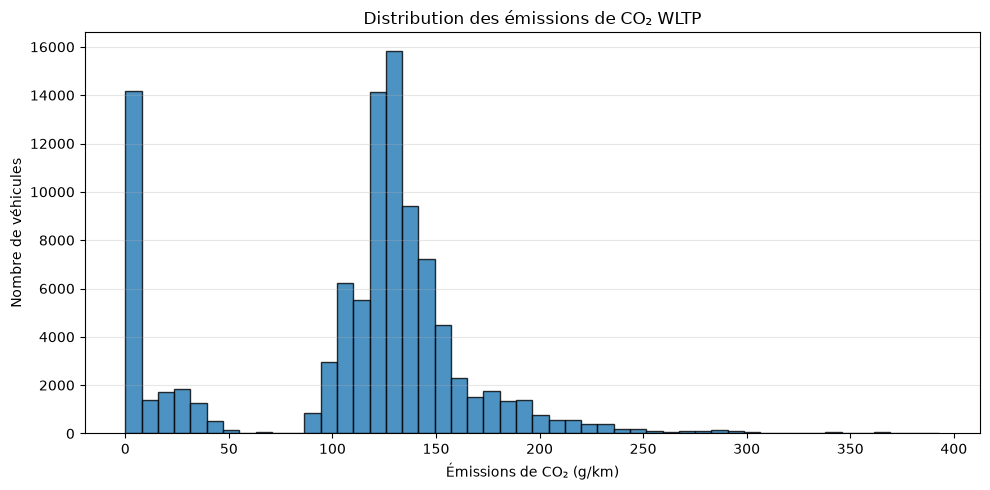

In [31]:
# ---------------------------------------------------------------------
# Visualisation de la distribution de la cible
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df[TARGET],
    bins=50,
    edgecolor="black",
    alpha=0.8,
)

ax.set_title("Distribution des émissions de CO₂ WLTP")
ax.set_xlabel("Émissions de CO₂ (g/km)")
ax.set_ylabel("Nombre de véhicules")

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

L'histogramme met en évidence plusieurs zones de concentration ainsi qu'une
partie supérieure de distribution moins dense correspondant aux véhicules
les plus fortement émetteurs.

La présence de valeurs élevées ne suffit cependant pas à les qualifier de
valeurs aberrantes.

Une investigation complémentaire est donc réalisée afin d'identifier les
profils de véhicules concernés avant toute décision de traitement.

### 9.6 Investigation des valeurs élevées d'émissions de CO₂

#### 9.6.1 Identification statistique des émissions élevées

Le 99ᵉ percentile de la variable cible est utilisé comme seuil
d'investigation de la partie supérieure de la distribution.

Ce seuil constitue un outil d'analyse et non un critère automatique
d'identification ou de suppression de valeurs aberrantes.

Les observations situées au-delà de ce percentile sont isolées afin
d'en mesurer la fréquence et d'en analyser les caractéristiques métier.

In [32]:
# ---------------------------------------------------------------------
# Investigation de la partie supérieure de la distribution de la cible
# ---------------------------------------------------------------------

HIGH_EMISSION_QUANTILE = 0.99

high_emission_threshold = df[TARGET].quantile(
    HIGH_EMISSION_QUANTILE
)

high_emission_df = df.loc[
    df[TARGET] > high_emission_threshold
].copy()

print(
    f"Seuil d'investigation (99e percentile) : "
    f"{high_emission_threshold:.2f} g/km"
)

print(
    f"Nombre d'observations au-dessus du seuil : "
    f"{len(high_emission_df):,}"
)

print(
    f"Part du jeu de données : "
    f"{len(high_emission_df) / len(df) * 100:.2f}%"
)

print(
    f"Émission maximale observée : "
    f"{high_emission_df[TARGET].max():.2f} g/km"
)

Seuil d'investigation (99e percentile) : 244.00 g/km
Nombre d'observations au-dessus du seuil : 989
Part du jeu de données : 0.99%
Émission maximale observée : 393.00 g/km


#### 9.6.2 Analyse des émissions élevées par type de motorisation

Les observations situées au-delà du seuil d'investigation sont analysées
selon leur type de motorisation.

Cette analyse vise à déterminer si les niveaux élevés d'émissions sont
associés à des profils de véhicules cohérents sur le plan métier ou s'ils
révèlent des observations nécessitant une investigation complémentaire.

Aucune observation n'est supprimée à cette étape.

In [33]:
# ---------------------------------------------------------------------
# Analyse des émissions élevées par type de motorisation
# ---------------------------------------------------------------------

high_emission_by_fuel = (
    high_emission_df
    .groupby("fuel_type")[TARGET]
    .agg(
        vehicles="size",
        mean_co2="mean",
        median_co2="median",
        max_co2="max",
    )
    .sort_values("vehicles", ascending=False)
    .round(2)
)

display(high_emission_by_fuel)

,vehicles,mean_co2,median_co2,max_co2
fuel_type,,,,
petrol,890,287.60,282.0,393.0
diesel,94,278.18,278.0,322.0
petrol/electric,5,260.80,260.0,273.0


#### 9.6.3 Décision sur les valeurs élevées d'émissions

L'analyse statistique et la répartition par type de motorisation montrent
que les observations situées dans la partie supérieure de la distribution
correspondent à des profils de véhicules plausibles sur le plan métier.

Ces niveaux élevés d'émissions ne sont donc pas considérés, à ce stade,
comme des valeurs aberrantes devant être supprimées automatiquement.

Ils constituent au contraire une information importante pour un modèle
destiné à prédire l'ensemble du spectre des émissions de CO₂, y compris
les véhicules fortement émetteurs.

**Décision :** les observations à fortes émissions sont conservées.
Aucun filtrage automatique fondé uniquement sur un percentile, l'IQR ou
un écart à la moyenne n'est appliqué à la variable cible.

## 10. Sélection et justification des variables à conserver

### 10.1 Identification des variables techniques et d'identification

Certaines variables décrivent directement les caractéristiques physiques,
énergétiques ou administratives du véhicule, tandis que d'autres constituent
principalement des identifiants techniques ou des références administratives.

Ces dernières nécessitent une attention particulière avant la modélisation :

- une forte cardinalité ne constitue pas, à elle seule, un motif de suppression ;
- un identifiant technique unique peut permettre de tracer une observation,
  tout en n'apportant aucune information généralisable au modèle ;
- certaines références administratives peuvent indirectement contenir une
  information sur le véhicule et doivent donc être analysées avant exclusion.

L'objectif de cette étape est d'identifier les variables candidates à
l'exclusion du futur jeu de caractéristiques (`X`) sans supprimer
prématurément des informations utiles au dataset nettoyé.

In [34]:
# ---------------------------------------------------------------------
# Audit des variables techniques et d'identification
# ---------------------------------------------------------------------

identifier_candidates = [
    "vehicle_record_id",
    "vehicle_family_id",
    "type_approval_number",
    "vehicle_type",
    "vehicle_variant",
    "vehicle_version",
    "commercial_name",
    "rlfi",
]

identifier_report = []

for column in identifier_candidates:

    if column not in df.columns:
        continue

    non_missing_count = df[column].notna().sum()
    unique_count = df[column].nunique(dropna=True)

    uniqueness_rate = (
        unique_count / non_missing_count * 100
        if non_missing_count > 0
        else 0
    )

    identifier_report.append(
        {
            "column": column,
            "dtype": str(df[column].dtype),
            "missing_count": df[column].isna().sum(),
            "unique_values": unique_count,
            "uniqueness_rate_pct": round(uniqueness_rate, 2),
        }
    )

identifier_report = (
    pd.DataFrame(identifier_report)
    .sort_values(
        "uniqueness_rate_pct",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(identifier_report)

,column,dtype,missing_count,unique_values,uniqueness_rate_pct
0,vehicle_record_id,int64,0,99791,100.00
1,vehicle_version,object,255,7062,7.09
2,vehicle_family_id,object,363,2988,3.01
3,vehicle_variant,object,231,2222,2.23
4,commercial_name,object,3,2056,2.06
5,type_approval_number,object,0,1642,1.65
6,rlfi,object,1690,1545,1.57
7,vehicle_type,object,16,508,0.51


### 10.2 Classification du rôle des variables techniques

L'analyse d'unicité montre que `vehicle_record_id` constitue un identifiant
technique unique : chaque observation possède sa propre valeur.

Cette variable est utile pour la traçabilité, l'audit et le rapprochement
avec les données sources, mais ne constitue pas une caractéristique
généralisable du véhicule pour l'apprentissage automatique.

Elle sera donc :

- conservée dans le dataset nettoyé pour assurer la traçabilité ;
- exclue ultérieurement du jeu de variables explicatives (`X`) utilisé
  pour la modélisation.

Les autres variables analysées présentent plusieurs observations par modalité.
Elles ne peuvent donc pas être assimilées à de simples identifiants uniques.

Leur conservation comme variables explicatives sera évaluée ultérieurement
selon leur signification métier, leur redondance, leur cardinalité et leur
risque de surapprentissage.

### 10.3 Gestion des variables constantes détectées en mode test

Plusieurs variables ont été identifiées comme constantes sur l'échantillon
de développement, notamment :

- `vehicle_category` ;
- `new_registrations` ;
- `status` ;
- `registration_year`.

Ces résultats étant obtenus en `TEST_MODE` sur un sous-ensemble du dataset,
aucune suppression définitive n'est réalisée sur cette seule base.

Le caractère constant de ces variables doit être confirmé lors de
l'exécution du pipeline sur l'ensemble du jeu de données.

Si leur cardinalité reste égale à `1` sur le dataset complet, elles seront
considérées comme non informatives et supprimées conformément à la stratégie
définie dans la section 6.

### 10.4 Analyse des redondances potentielles entre variables

Plusieurs variables du dataset décrivent des informations proches ou
hiérarchiquement liées. Leur présence simultanée peut introduire de la
redondance et augmenter inutilement la complexité du futur modèle.

L'objectif de cette étape est d'identifier les relations fortes entre ces
variables avant toute décision de conservation ou d'exclusion.

Une première analyse porte sur les variables relatives au constructeur :

- `manufacturer_pool` ;
- `manufacturer_name_eu` ;
- `manufacturer_name_oem` ;
- `manufacturer_make`.

L'analyse cherche notamment à déterminer si une modalité d'une variable
correspond systématiquement, ou presque systématiquement, à une modalité
d'une autre variable.

Aucune variable n'est supprimée à cette étape.

#### 10.4.1 Relations entre les variables relatives au constructeur

Les variables décrivant le constructeur sont comparées deux à deux afin
d'évaluer leur degré de dépendance.

Pour chaque paire, on mesure le nombre moyen et maximal de modalités de la
seconde variable associées à une modalité de la première.

Une correspondance proche de `1 → 1` peut révéler une forte redondance,
tandis qu'une relation `1 → plusieurs` indique que les variables décrivent
des niveaux d'information différents.

In [35]:
# ---------------------------------------------------------------------
# Analyse des relations entre variables constructeur
# ---------------------------------------------------------------------

manufacturer_columns = [
    "manufacturer_pool",
    "manufacturer_name_eu",
    "manufacturer_name_oem",
    "manufacturer_make",
]

manufacturer_relation_report = []

for source_column in manufacturer_columns:
    for target_column in manufacturer_columns:

        if source_column == target_column:
            continue

        relation = (
            df[[source_column, target_column]]
            .dropna()
            .groupby(source_column)[target_column]
            .nunique()
        )

        manufacturer_relation_report.append(
            {
                "source_variable": source_column,
                "target_variable": target_column,
                "source_modalities": relation.size,
                "mean_target_per_source": round(relation.mean(), 2),
                "median_target_per_source": round(relation.median(), 2),
                "max_target_per_source": relation.max(),
                "one_to_one_rate_pct": round(
                    relation.eq(1).mean() * 100,
                    2,
                ),
            }
        )

manufacturer_relation_report = pd.DataFrame(
    manufacturer_relation_report
)

display(manufacturer_relation_report)

,source_variable,target_variable,source_modalities,mean_target_per_source,median_target_per_source,max_target_per_source,one_to_one_rate_pct
0,manufacturer_pool,manufacturer_name_eu,11,4.45,3.0,9,0.00
1,manufacturer_pool,manufacturer_name_oem,11,4.45,3.0,9,0.00
2,manufacturer_pool,manufacturer_make,11,3.91,3.0,9,18.18
3,manufacturer_name_eu,manufacturer_pool,49,1.00,1.0,1,100.00
4,manufacturer_name_eu,manufacturer_name_oem,86,1.13,1.0,12,98.84
5,manufacturer_name_eu,manufacturer_make,86,1.81,1.0,32,75.58
6,manufacturer_name_oem,manufacturer_pool,49,1.00,1.0,1,100.00
7,manufacturer_name_oem,manufacturer_name_eu,84,1.15,1.0,3,85.71
8,manufacturer_name_oem,manufacturer_make,84,1.74,1.0,32,76.19
9,manufacturer_make,manufacturer_pool,43,1.00,1.0,1,100.00


#### 10.4.2 Relations entre type, variante et version du véhicule

Les variables `vehicle_type`, `vehicle_variant` et `vehicle_version`
décrivent différents niveaux de caractérisation technique du véhicule.

Leur forte cardinalité ne justifie pas automatiquement leur exclusion.

Cette étape analyse les relations entre ces trois variables afin de déterminer
si elles correspondent à des niveaux hiérarchiques distincts ou si certaines
d'entre elles apportent une information largement redondante.

Pour chaque paire de variables, l'analyse mesure notamment :

- le nombre de modalités de la variable source ;
- le nombre moyen de modalités cibles associées ;
- le nombre médian de modalités cibles ;
- le nombre maximal de modalités cibles ;
- la proportion de relations de type `1 → 1`.

Aucune variable n'est supprimée à cette étape.

In [36]:
# ---------------------------------------------------------------------
# Analyse des relations entre type, variante et version du véhicule
# ---------------------------------------------------------------------

vehicle_structure_columns = [
    "vehicle_type",
    "vehicle_variant",
    "vehicle_version",
]

vehicle_structure_report = []

for source_column in vehicle_structure_columns:
    for target_column in vehicle_structure_columns:

        if source_column == target_column:
            continue

        relation = (
            df[[source_column, target_column]]
            .dropna()
            .groupby(source_column)[target_column]
            .nunique()
        )

        vehicle_structure_report.append(
            {
                "source_variable": source_column,
                "target_variable": target_column,
                "source_modalities": relation.size,
                "mean_target_per_source": round(relation.mean(), 2),
                "median_target_per_source": round(relation.median(), 2),
                "max_target_per_source": relation.max(),
                "one_to_one_rate_pct": round(
                    relation.eq(1).mean() * 100,
                    2,
                ),
            }
        )

vehicle_structure_report = pd.DataFrame(
    vehicle_structure_report
)

display(vehicle_structure_report)

,source_variable,target_variable,source_modalities,mean_target_per_source,median_target_per_source,max_target_per_source,one_to_one_rate_pct
0,vehicle_type,vehicle_variant,482,5.31,2.0,64,33.40
1,vehicle_type,vehicle_version,468,16.46,4.0,304,23.72
2,vehicle_variant,vehicle_type,2222,1.15,1.0,16,90.95
3,vehicle_variant,vehicle_version,2205,4.48,2.0,148,34.20
4,vehicle_version,vehicle_type,7061,1.09,1.0,12,93.67
5,vehicle_version,vehicle_variant,7061,1.40,1.0,45,81.87


**Conclusion :**

Les variables `vehicle_type`, `vehicle_variant` et `vehicle_version`
présentent une organisation globalement hiérarchique, du niveau le plus
général (`vehicle_type`) au niveau le plus détaillé (`vehicle_version`).

Les relations observées ne sont toutefois pas strictement bijectives :
une variante ou une version peut, dans certains cas, être associée à plusieurs
modalités du niveau supérieur.

Ces variables sont donc conservées dans le dataset nettoyé.

Leur utilisation simultanée comme variables explicatives sera réévaluée lors
du Feature Engineering, notamment au regard de leur forte cardinalité, de leur
redondance potentielle et du risque de surapprentissage.

### 10.5 Synthèse des décisions de conservation des variables

À l'issue des contrôles de qualité, de cardinalité, d'unicité et de redondance,
les variables sont classées selon leur rôle dans le projet et la décision
retenue à l'issue de cette phase de nettoyage.

Cette classification distingue notamment :

- les variables métier conservées ;
- la variable cible ;
- l'identifiant technique conservé pour la traçabilité mais destiné à être
  exclu des futures variables explicatives ;
- les variables constantes potentielles dont le statut devra être confirmé
  sur le dataset complet ;
- les variables à forte cardinalité conservées dans le dataset nettoyé mais
  dont l'utilisation pour la modélisation sera réévaluée lors du Feature
  Engineering.

Cette étape ne constitue pas encore une sélection définitive des features
du modèle. Elle formalise les décisions prises au niveau du nettoyage et de
la préparation des données.

In [37]:
# ---------------------------------------------------------------------
# Registre des décisions de conservation des variables
# ---------------------------------------------------------------------

TARGET = "co2_wltp_g_km"

TRACEABILITY_COLUMNS = {
    "vehicle_record_id",
}

CONSTANT_CANDIDATES = set(constant_columns)

HIGH_CARDINALITY_COLUMNS = {
    "vehicle_type",
    "vehicle_variant",
    "vehicle_version",
    "vehicle_family_id",
    "type_approval_number",
    "commercial_name",
    "rlfi",
}

variable_registry = []

for column in df.columns:

    # -------------------------------------------------------------
    # Classification du rôle
    # -------------------------------------------------------------

    if column == TARGET:
        role = "target"
        decision = "keep"
        rationale = "Variable cible de la régression."

    elif column in TRACEABILITY_COLUMNS:
        role = "technical_identifier"
        decision = "keep_for_traceability"
        rationale = (
            "Identifiant technique conservé pour la traçabilité ; "
            "à exclure des futures variables explicatives."
        )

    elif column in CONSTANT_CANDIDATES:
        role = "potential_constant"
        decision = "confirm_on_full_dataset"
        rationale = (
            "Variable constante sur l'échantillon ; "
            "statut à confirmer sur le dataset complet."
        )

    elif column in HIGH_CARDINALITY_COLUMNS:
        role = "high_cardinality_feature"
        decision = "keep_for_feature_engineering"
        rationale = (
            "Variable conservée dans le dataset nettoyé ; "
            "utilisation à réévaluer lors du Feature Engineering."
        )

    else:
        role = "business_feature"
        decision = "keep"
        rationale = (
            "Variable métier conservée à l'issue "
            "des contrôles de nettoyage."
        )

    variable_registry.append(
        {
            "variable": column,
            "dtype": str(df[column].dtype),
            "role": role,
            "decision": decision,
            "rationale": rationale,
        }
    )


variable_registry = pd.DataFrame(variable_registry)

display(variable_registry)

,variable,dtype,role,decision,rationale
0,vehicle_record_id,int64,technical_identifier,keep_for_traceability,Identifiant technique conservé pour la traçabi...
1,country,object,business_feature,keep,Variable métier conservée à l'issue des contrô...
2,vehicle_family_id,object,high_cardinality_feature,keep_for_feature_engineering,Variable conservée dans le dataset nettoyé ; u...
3,manufacturer_pool,object,business_feature,keep,Variable métier conservée à l'issue des contrô...
4,manufacturer_name_eu,object,business_feature,keep,Variable métier conservée à l'issue des contrô...
5,manufacturer_name_oem,object,business_feature,keep,Variable métier conservée à l'issue des contrô...
6,type_approval_number,object,high_cardinality_feature,keep_for_feature_engineering,Variable conservée dans le dataset nettoyé ; u...
7,vehicle_type,object,high_cardinality_feature,keep_for_feature_engineering,Variable conservée dans le dataset nettoyé ; u...
8,vehicle_variant,object,high_cardinality_feature,keep_for_feature_engineering,Variable conservée dans le dataset nettoyé ; u...
9,vehicle_version,object,high_cardinality_feature,keep_for_feature_engineering,Variable conservée dans le dataset nettoyé ; u...


## 11. Contrôle qualité final du dataset nettoyé

Avant l'export du dataset nettoyé, un contrôle qualité final est réalisé afin
de vérifier la cohérence des transformations appliquées au cours du
prétraitement.

Les contrôles portent notamment sur :

- les dimensions finales du dataset ;
- l'unicité de l'identifiant technique ;
- l'absence de doublons complets ;
- l'absence de valeurs manquantes sur la variable cible ;
- le type de la variable temporelle ;
- la présence des colonnes indispensables ;
- la cohérence générale du schéma obtenu.

Ce contrôle constitue une étape de validation avant la génération du dataset
nettoyé destiné aux étapes analytiques suivantes.

### 11.1 Contrôles structurels du dataset

In [38]:
# ---------------------------------------------------------------------
# Contrôles structurels du dataset nettoyé
# ---------------------------------------------------------------------

print(f"Nombre d'observations : {len(df):,}")
print(f"Nombre de variables    : {df.shape[1]}")
print()

quality_checks = {
    "Identifiant technique sans valeur manquante":
        df["vehicle_record_id"].notna().all(),

    "Identifiant technique unique":
        df["vehicle_record_id"].is_unique,

    "Absence de doublons complets":
        not df.duplicated().any(),

    "Variable cible sans valeur manquante":
        df[TARGET].notna().all(),

    "Date d'immatriculation au format datetime":
        pd.api.types.is_datetime64_any_dtype(
            df["registration_date"]
        ),

    "manufacturer_make sans valeur numérique":
    not (
        df["manufacturer_make"]
        .dropna()
        .astype("string")
        .str.strip()
        .str.fullmatch(r"\d+", na=False)
        .any()
    ),

    "vehicle_category_type en majuscules":
        (
            df["vehicle_category_type"]
            .dropna()
            .astype("string")
            .eq(
                df["vehicle_category_type"]
                .dropna()
                .astype("string")
                .str.upper()
            )
            .all()
        ),

    "fuel_mode en majuscules":
        (
            df["fuel_mode"]
            .dropna()
            .astype("string")
            .eq(
                df["fuel_mode"]
                .dropna()
                .astype("string")
                .str.upper()
            )
            .all()
        ),
    }

for check, result in quality_checks.items():
    status = "✅" if result else "❌"
    print(f"{status} {check}")

Nombre d'observations : 99,791
Nombre de variables    : 32

✅ Identifiant technique sans valeur manquante
✅ Identifiant technique unique
✅ Absence de doublons complets
✅ Variable cible sans valeur manquante
✅ Date d'immatriculation au format datetime
✅ manufacturer_make sans valeur numérique
✅ vehicle_category_type en majuscules
✅ fuel_mode en majuscules


### 11.2 Contrôle des variables indispensables

Avant l'export du dataset nettoyé, un contrôle explicite est réalisé sur un
ensemble minimal de variables considérées comme indispensables pour la suite
du projet.

Ces variables couvrent notamment :

- la traçabilité des enregistrements ;
- les caractéristiques principales du véhicule ;
- les informations techniques liées à la motorisation ;
- la variable cible de régression ;
- la dimension temporelle.

L'objectif est de vérifier qu'aucune variable essentielle n'a été supprimée
accidentellement au cours des différentes étapes de nettoyage et de
prétraitement.

Ce contrôle porte uniquement sur la présence des variables attendues dans le
schéma final du dataset.

In [39]:
# ---------------------------------------------------------------------
# Vérification des variables indispensables
# ---------------------------------------------------------------------

required_columns = {
    "vehicle_record_id",
    "country",
    "manufacturer_name_eu",
    "manufacturer_make",
    "vehicle_category_type",
    "fuel_type",
    "fuel_mode",
    "mass_running_order_kg",
    "co2_wltp_g_km",
    "engine_capacity_cm3",
    "engine_power_kw",
    "registration_date",
}

missing_required_columns = sorted(
    required_columns - set(df.columns)
)

if missing_required_columns:
    print("❌ Variables indispensables manquantes :")

    for column in missing_required_columns:
        print(f"- {column}")

else:
    print(
        "✅ Toutes les variables indispensables "
        "sont présentes."
    )

✅ Toutes les variables indispensables sont présentes.


## 12. Export du dataset nettoyé

Le dataset ayant passé les contrôles de qualité, il peut être exporté vers
le répertoire `data/processed/`.

L'export distingue deux situations :

- **Mode test** : le dataset contient uniquement un sous-ensemble des données
  et sert à valider le pipeline de preprocessing ;
- **Mode complet** : le pipeline est exécuté sur l'ensemble du dataset source
  et produit le dataset nettoyé destiné aux étapes suivantes du projet.

Cette distinction permet d'éviter qu'un dataset d'échantillonnage soit
accidentellement utilisé comme dataset de production.

### 12.1 Définition de la stratégie d'export

Le nom du fichier de sortie dépend du mode d'exécution.

En mode test, le fichier est explicitement identifié comme un échantillon
de validation.

En mode complet, le fichier correspond au dataset nettoyé de référence.

In [40]:
# ---------------------------------------------------------------------
# Définition du fichier de sortie selon le mode d'exécution
# ---------------------------------------------------------------------

if TEST_MODE:
    OUTPUT_DATA_PATH = (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "data_2024_cleaned_test.csv"
    )
else:
    OUTPUT_DATA_PATH = (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "data_2024_cleaned.csv"
    )

print(f"Mode d'exécution : {'TEST' if TEST_MODE else 'COMPLET'}")
print(f"Fichier de sortie : {OUTPUT_DATA_PATH}")

Mode d'exécution : TEST
Fichier de sortie : /home/jmbandong/projects/ml-projects/vehicle-emissions-prediction-mlops/data/processed/data_2024_cleaned_test.csv


### 12.2 Export du dataset nettoyé

Le dataset nettoyé est maintenant écrit dans le répertoire `data/processed/`.

L'export utilise le chemin défini précédemment selon le mode d'exécution afin
de distinguer clairement un échantillon de validation du dataset complet.

L'index Pandas n'est pas exporté, car il ne constitue pas une variable métier
du dataset.

In [41]:
# ---------------------------------------------------------------------
# Export du dataset nettoyé
# ---------------------------------------------------------------------

OUTPUT_DATA_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

df.to_csv(
    OUTPUT_DATA_PATH,
    index=False,
)

print("✅ Dataset nettoyé exporté avec succès.")
print(f"Fichier : {OUTPUT_DATA_PATH}")
print(f"Observations : {len(df):,}")
print(f"Variables    : {df.shape[1]}")

✅ Dataset nettoyé exporté avec succès.
Fichier : /home/jmbandong/projects/ml-projects/vehicle-emissions-prediction-mlops/data/processed/data_2024_cleaned_test.csv
Observations : 99,791
Variables    : 32


### 12.3 Vérification du dataset exporté

Après l'export, le fichier généré est relu depuis le disque afin de vérifier
que l'écriture s'est correctement déroulée et que le dataset exporté reste
cohérent avec le DataFrame en mémoire.

Les contrôles portent sur :

- l'existence physique du fichier ;
- ses dimensions après relecture ;
- la cohérence du nombre de lignes et de colonnes ;
- la présence de la variable cible ;
- l'absence de valeurs manquantes sur la cible.

In [42]:
# ---------------------------------------------------------------------
# Vérification du fichier exporté
# ---------------------------------------------------------------------

if not OUTPUT_DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Fichier exporté introuvable : {OUTPUT_DATA_PATH}"
    )

df_exported = pd.read_csv(
    OUTPUT_DATA_PATH,
    low_memory=False,
    parse_dates=["registration_date"],
)

print(f"✅ Fichier présent : {OUTPUT_DATA_PATH}")
print(f"Observations relues : {len(df_exported):,}")
print(f"Variables relues    : {df_exported.shape[1]}")

assert len(df_exported) == len(df), (
    "Le nombre de lignes du fichier exporté "
    "diffère du DataFrame en mémoire."
)

assert df_exported.shape[1] == df.shape[1], (
    "Le nombre de colonnes du fichier exporté "
    "diffère du DataFrame en mémoire."
)

assert TARGET in df_exported.columns, (
    f"La variable cible '{TARGET}' est absente du fichier exporté."
)

assert df_exported[TARGET].notna().all(), (
    "Des valeurs manquantes subsistent dans la variable cible."
)

assert pd.api.types.is_datetime64_any_dtype(
    df_exported["registration_date"]
), (
    "La colonne 'registration_date' n'a pas été restaurée "
    "correctement au format datetime."
)

print("✅ Dataset exporté et vérifié avec succès.")

✅ Fichier présent : /home/jmbandong/projects/ml-projects/vehicle-emissions-prediction-mlops/data/processed/data_2024_cleaned_test.csv
Observations relues : 99,791
Variables relues    : 32
✅ Dataset exporté et vérifié avec succès.
